# 📡 Обнаружение дронов по данным FMCW-радара

**ВКР: Разработка системы обнаружения и распознавания дронов (радар-модуль)**

### Датасет
**Real Doppler RAD-DAR Database**
- FMCW радар (8.75 ГГц, 500 МГц полоса)
- ~17 000+ range-Doppler матриц (CSV)
- 3 класса: **Cars**, **Drones**, **People**

**Подключение:** Add Data → `real-doppler-raddar-database` (iroldan)

In [1]:
import os, json, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | {DEVICE}')
if torch.cuda.is_available(): print(f'GPU: {torch.cuda.get_device_name(0)}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

WORK_DIR = Path('/kaggle/working')
VIZ_DIR = WORK_DIR / 'visualizations'
MODEL_DIR = WORK_DIR / 'models'
for d in [VIZ_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3
WD = 1e-4
PATIENCE = 10

print('✅ Готово')

PyTorch 2.10.0+cu128 | cuda
GPU: Tesla T4
✅ Готово


---
## 1. Поиск и загрузка данных

In [2]:
# ============================================================
# Поиск RAD-DAR датасета в /kaggle/input
# ============================================================

KAGGLE_INPUT = Path('/kaggle/input')

# Ищем все CSV файлы рекурсивно
all_csvs = list(KAGGLE_INPUT.rglob('*.csv'))
print(f'📂 Всего CSV в /kaggle/input: {len(all_csvs)}')

# Показать структуру
print('\n📁 Папки с CSV:')
csv_dirs = set()
for f in all_csvs[:5000]:
    rel = f.relative_to(KAGGLE_INPUT)
    # Ищем папки с ключевыми словами
    for part in rel.parts:
        if part.lower() in ['cars', 'drones', 'people', 'drone']:
            csv_dirs.add(part)

print(f'   Найденные классы: {csv_dirs}')
if all_csvs:
    print(f'   Пример пути: {all_csvs[0]}')

📂 Всего CSV в /kaggle/input: 34970

📁 Папки с CSV:
   Найденные классы: {'Cars'}
   Пример пути: /kaggle/input/datasets/iroldan/real-doppler-raddar-database/Cars/13-54/028.csv


In [3]:
# ============================================================
# Сбор файлов: определяем класс по пути
# ============================================================

CLASS_KEYWORDS = {
    'Cars': ['cars', 'car', 'vehicle'],
    'Drones': ['drones', 'drone', 'uav'],
    'People': ['people', 'person', 'pedestrian', 'human'],
}

def detect_class(filepath):
    """Определить класс по любой части пути."""
    path_lower = str(filepath).lower()
    for cls_name, keywords in CLASS_KEYWORDS.items():
        for kw in keywords:
            if f'/{kw}/' in path_lower or f'/{kw}' in path_lower:
                return cls_name
    return None

records = []
skipped = 0
for f in tqdm(all_csvs, desc='Сбор файлов'):
    # Пропускаем metadata CSV (маленькие, с заголовками)
    if f.stat().st_size < 100:  # слишком маленький
        skipped += 1
        continue
    if f.name in ['class_stats.csv', 'SNR_stats.csv']:  # метаданные
        skipped += 1
        continue
    
    cls = detect_class(f)
    if cls is not None:
        records.append({'path': str(f), 'class_name': cls})

df = pd.DataFrame(records)

print(f'\n📊 Собрано: {len(df)} range-Doppler карт (пропущено: {skipped})')

if len(df) == 0:
    print('\n❌ Не найдено данных! Проверяем все пути:')
    for f in all_csvs[:20]:
        print(f'   {f}')
    raise FileNotFoundError('CSV не распознаны. Проверь структуру датасета.')

# Кодирование
class_names = sorted(df['class_name'].unique())
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df['label'] = df['class_name'].map(class_to_idx)
NUM_CLASSES = len(class_names)

print(f'\n   Классы ({NUM_CLASSES}):')
for cls in class_names:
    cnt = (df['class_name'] == cls).sum()
    print(f'   {cls:10s}: {cnt}')

Сбор файлов:   0%|          | 0/34970 [00:00<?, ?it/s]


📊 Собрано: 34970 range-Doppler карт (пропущено: 0)

   Классы (3):
   Cars      : 11440
   Drones    : 10130
   People    : 13400


In [4]:
# ============================================================
# Проверка формата CSV
# ============================================================

sample_path = df.iloc[0]['path']
sample_data = pd.read_csv(sample_path, header=None).values
RD_ROWS, RD_COLS = sample_data.shape

print(f'📐 Формат одной RD-карты:')
print(f'   Размер: {RD_ROWS} × {RD_COLS} (range × Doppler)')
print(f'   Значения: [{sample_data.min():.2f}, {sample_data.max():.2f}]')
print(f'   Dtype: {sample_data.dtype}')

📐 Формат одной RD-карты:
   Размер: 11 × 61 (range × Doppler)
   Значения: [-144.55, -84.42]
   Dtype: float64


---
## 2. EDA

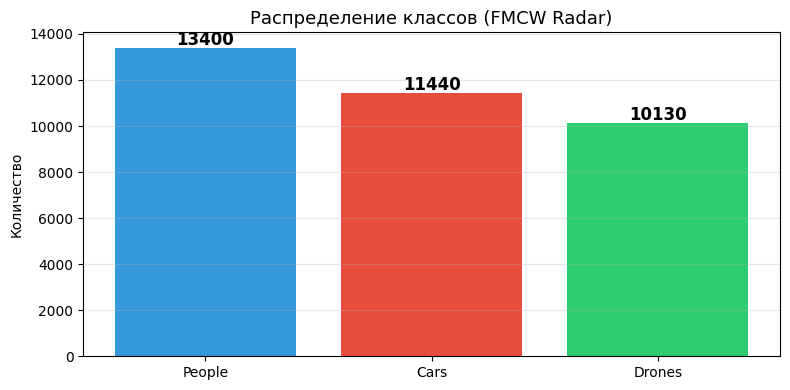

In [5]:
# Распределение классов
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['class_name'].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.bar(counts.index, counts.values, color=colors[:len(counts)])
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+max(counts)*0.01,
            str(v), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Распределение классов (FMCW Radar)', fontsize=13)
ax.set_ylabel('Количество')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(VIZ_DIR/'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

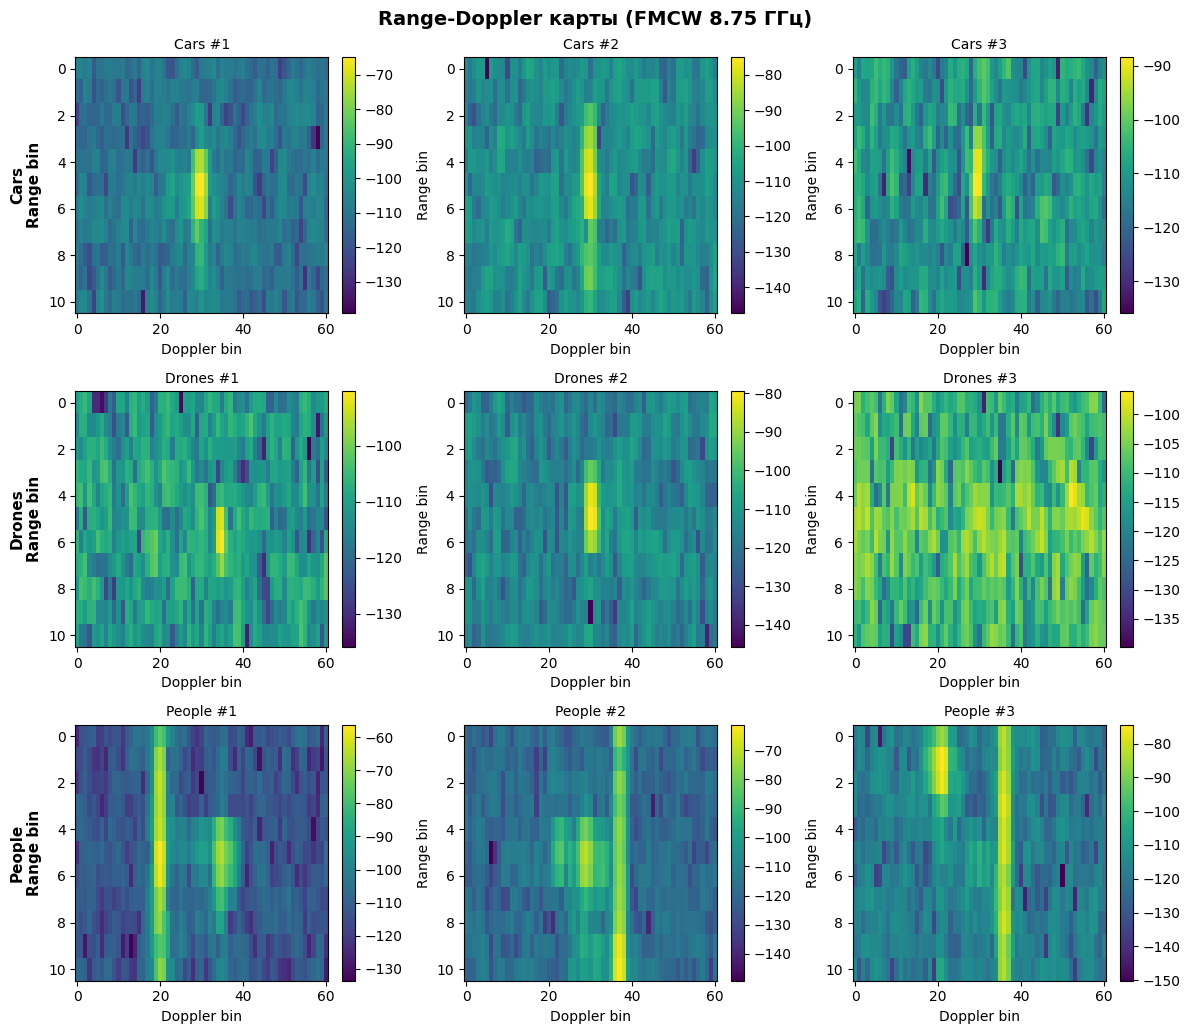

In [6]:
# Примеры RD-карт
n_examples = 3
fig, axes = plt.subplots(NUM_CLASSES, n_examples, figsize=(4*n_examples, 3.5*NUM_CLASSES))
if NUM_CLASSES == 1: axes = axes.reshape(1, -1)

for row, cls_name in enumerate(class_names):
    samples = df[df['class_name']==cls_name].sample(n_examples, random_state=SEED)
    for col, (_, s) in enumerate(samples.iterrows()):
        rd = pd.read_csv(s['path'], header=None).values
        ax = axes[row, col]
        im = ax.imshow(rd, aspect='auto', cmap='viridis', interpolation='nearest')
        ax.set_xlabel('Doppler bin')
        if col == 0:
            ax.set_ylabel(f'{cls_name}\nRange bin', fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('Range bin')
        ax.set_title(f'{cls_name} #{col+1}', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Range-Doppler карты (FMCW 8.75 ГГц)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_DIR/'rd_map_examples.png', dpi=150, bbox_inches='tight')
plt.show()

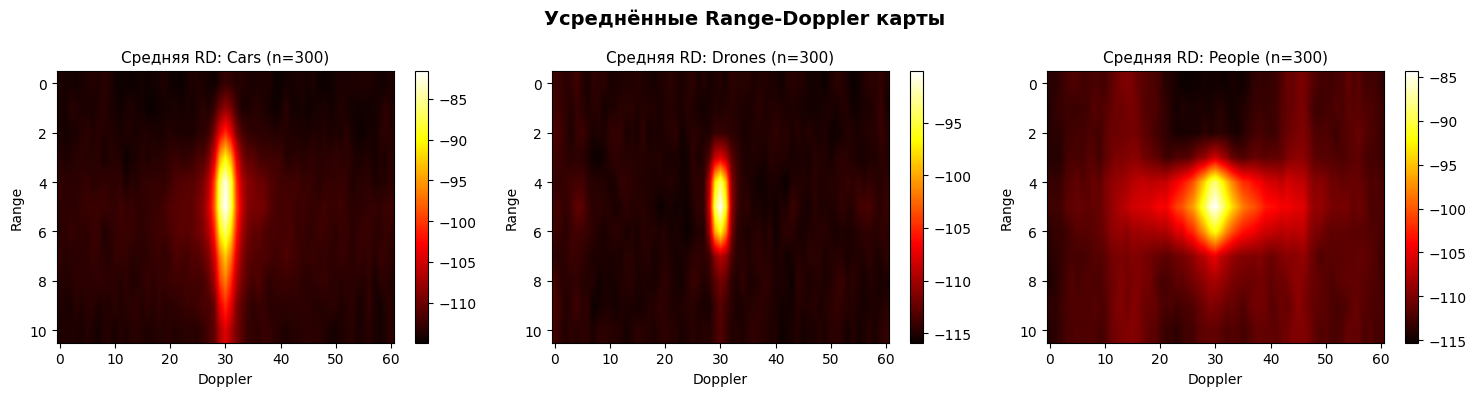

In [7]:
# Средние RD-карты по классам
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5*NUM_CLASSES, 4))
if NUM_CLASSES == 1: axes = [axes]

for i, cls_name in enumerate(class_names):
    cls_df = df[df['class_name']==cls_name].sample(min(300, (df['class_name']==cls_name).sum()),
                                                    random_state=SEED)
    maps = []
    for _, row in cls_df.iterrows():
        try:
            m = pd.read_csv(row['path'], header=None).values
            if m.shape == (RD_ROWS, RD_COLS):
                maps.append(m)
        except: pass
    if maps:
        mean_map = np.mean(maps, axis=0)
        im = axes[i].imshow(mean_map, aspect='auto', cmap='hot', interpolation='bilinear')
        axes[i].set_title(f'Средняя RD: {cls_name} (n={len(maps)})', fontsize=11)
        axes[i].set_xlabel('Doppler'); axes[i].set_ylabel('Range')
        plt.colorbar(im, ax=axes[i])

plt.suptitle('Усреднённые Range-Doppler карты', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_DIR/'mean_rd_maps.png', dpi=150, bbox_inches='tight')
plt.show()

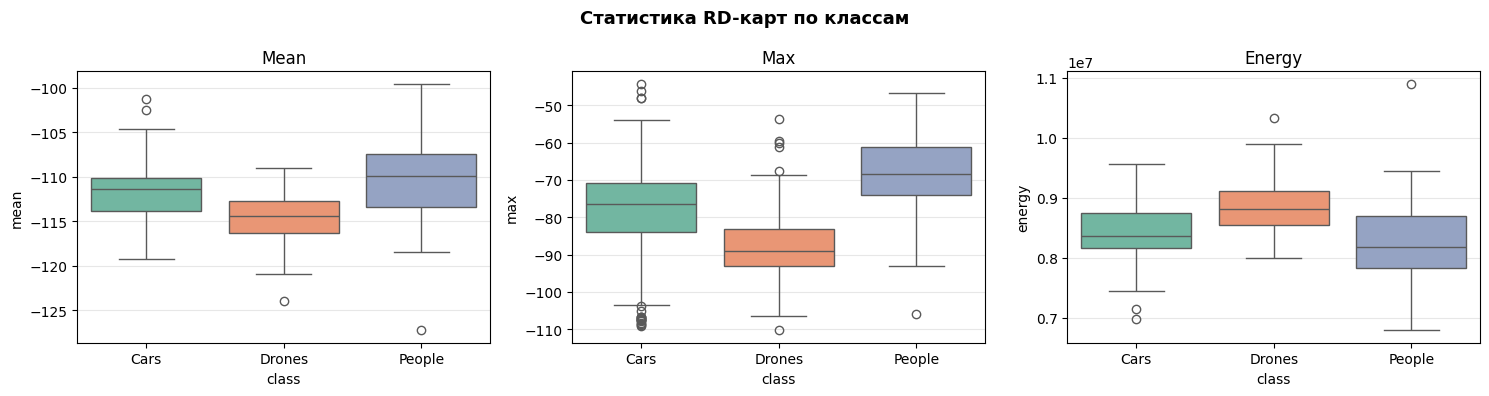

In [8]:
# Статистика
stats = []
for cls_name in class_names:
    cls_df = df[df['class_name']==cls_name].sample(min(300, (df['class_name']==cls_name).sum()),
                                                    random_state=SEED)
    for _, row in cls_df.iterrows():
        try:
            m = pd.read_csv(row['path'], header=None).values
            stats.append({'class': cls_name, 'mean': m.mean(), 'std': m.std(),
                          'max': m.max(), 'energy': np.sum(m**2)})
        except: pass

stats_df = pd.DataFrame(stats)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, metric in enumerate(['mean', 'max', 'energy']):
    sns.boxplot(data=stats_df, x='class', y=metric, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{metric.capitalize()}')
    axes[i].grid(axis='y', alpha=0.3)
plt.suptitle('Статистика RD-карт по классам', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_DIR/'signal_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Dataset и DataLoaders

In [9]:
class RadarRDDataset(Dataset):
    def __init__(self, filepaths, labels, rd_shape=(RD_ROWS, RD_COLS), augment=False):
        self.filepaths = filepaths
        self.labels = labels
        self.rd_shape = rd_shape
        self.augment = augment
    
    def __len__(self): return len(self.filepaths)
    
    def __getitem__(self, idx):
        try:
            m = pd.read_csv(self.filepaths[idx], header=None).values.astype(np.float32)
        except:
            m = np.zeros(self.rd_shape, dtype=np.float32)
        
        # Нормализация [0, 1]
        mn, mx = m.min(), m.max()
        if mx - mn > 1e-8:
            m = (m - mn) / (mx - mn)
        
        if self.augment:
            if np.random.rand() < 0.3:
                m = m + np.random.randn(*m.shape).astype(np.float32) * 0.05
                m = np.clip(m, 0, 1)
            if np.random.rand() < 0.3:
                m = m * np.random.uniform(0.8, 1.2)
                m = np.clip(m, 0, 1)
            if np.random.rand() < 0.5:
                m = np.flip(m, axis=1).copy()
        
        # (1, H, W)
        m = m[np.newaxis, ...]
        return torch.FloatTensor(m), torch.tensor(self.labels[idx], dtype=torch.long)


# Split
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.18, stratify=train_df['label'], random_state=SEED)

print(f'📊 Split:')
for name, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    d = sdf['class_name'].value_counts().to_dict()
    print(f'   {name:5s}: {len(sdf):5d}  {d}')

train_ds = RadarRDDataset(train_df['path'].tolist(), train_df['label'].tolist(), augment=True)
val_ds = RadarRDDataset(val_df['path'].tolist(), val_df['label'].tolist())
test_ds = RadarRDDataset(test_df['path'].tolist(), test_df['label'].tolist())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

bx, by = next(iter(train_loader))
print(f'\n   Batch: {bx.shape}  labels: {by[:8].tolist()}')

📊 Split:
   Train: 24373  {'People': 9340, 'Cars': 7973, 'Drones': 7060}
   Val  :  5351  {'People': 2050, 'Cars': 1751, 'Drones': 1550}
   Test :  5246  {'People': 2010, 'Cars': 1716, 'Drones': 1520}

   Batch: torch.Size([64, 1, 11, 61])  labels: [0, 0, 2, 1, 0, 0, 0, 1]


---
## 4. Модели

In [10]:
# Модель 1: DopplerNet (лёгкая CNN под маленькие RD-карты)
class DopplerNet(nn.Module):
    def __init__(self, nc):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.AdaptiveAvgPool2d((2,4)),
        )
        self.fc = nn.Sequential(
            nn.Flatten(), nn.Linear(128*2*4, 128), nn.ReLU(True),
            nn.Dropout(0.5), nn.Linear(128, nc),
        )
    def forward(self, x): return self.fc(self.conv(x))


# Модель 2: RadarResNet
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch,ch,3,padding=1), nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Conv2d(ch,ch,3,padding=1), nn.BatchNorm2d(ch),
        )
    def forward(self, x): return F.relu(self.block(x) + x)

class RadarResNet(nn.Module):
    def __init__(self, nc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            ResBlock(64), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            ResBlock(128), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            ResBlock(256),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.5),
        )
        self.head = nn.Linear(256, nc)
    def forward(self, x): return self.head(self.net(x))


# Модель 3: MLP baseline
class RadarMLP(nn.Module):
    def __init__(self, input_size, nc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(128, nc),
        )
    def forward(self, x): return self.net(x)


# Проверка
for name, m in [('DopplerNet', DopplerNet(NUM_CLASSES)),
                ('RadarResNet', RadarResNet(NUM_CLASSES)),
                ('MLP', RadarMLP(RD_ROWS*RD_COLS, NUM_CLASSES))]:
    p = sum(p.numel() for p in m.parameters())
    o = m(bx[:2])
    print(f'   {name:14s}: {p/1e3:.1f}K params, out={o.shape}')

   DopplerNet    : 271.1K params, out=torch.Size([2, 3])
   RadarResNet   : 1922.3K params, out=torch.Size([2, 3])
   MLP           : 510.5K params, out=torch.Size([2, 3])


---
## 5. Обучение

In [11]:
def train_model(model, tl, vl, epochs=EPOCHS, lr=LR, patience=PATIENCE, name='model'):
    model = model.to(DEVICE)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WD)
    sch = CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
    
    hist = {'tl':[],'vl':[],'ta':[],'va':[],'vf':[]}
    best_f1, wait, best_st = 0., 0, None
    
    for ep in range(epochs):
        model.train()
        ls, c, t = 0., 0, 0
        for x, y in tl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); o = model(x); l = crit(o,y); l.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.); opt.step()
            ls += l.item()*x.size(0); c += (o.argmax(1)==y).sum().item(); t += y.size(0)
        sch.step()
        
        model.eval()
        vls, ps, ys = 0., [], []
        with torch.no_grad():
            for x, y in vl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                o = model(x); vls += crit(o,y).item()*x.size(0)
                ps.extend(o.argmax(1).cpu().numpy()); ys.extend(y.cpu().numpy())
        
        tl_v, ta_v = ls/t, c/t
        vl_v = vls/len(ys); va_v = accuracy_score(ys,ps); vf_v = f1_score(ys,ps,average='macro')
        hist['tl'].append(tl_v); hist['vl'].append(vl_v)
        hist['ta'].append(ta_v); hist['va'].append(va_v); hist['vf'].append(vf_v)
        
        if vf_v > best_f1:
            best_f1, wait = vf_v, 0
            best_st = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            torch.save(model.state_dict(), MODEL_DIR/f'{name}_best.pt')
        else: wait += 1
        
        if (ep+1)%5==0 or ep==0:
            print(f'  Ep {ep+1:3d}/{epochs} │ loss={tl_v:.4f} acc={ta_v:.4f} │ '
                  f'v_loss={vl_v:.4f} v_acc={va_v:.4f} F1={vf_v:.4f}')
        if wait >= patience:
            print(f'  ⏹️ Early stop (ep {ep+1})')
            break
    
    if best_st: model.load_state_dict(best_st); model = model.to(DEVICE)
    print(f'  ✅ Best F1: {best_f1:.4f}')
    return model, hist

In [12]:
print('🚀 DopplerNet')
print('='*70)
m1, h1 = train_model(DopplerNet(NUM_CLASSES), train_loader, val_loader, name='dopplernet')

🚀 DopplerNet
  Ep   1/50 │ loss=0.2598 acc=0.8991 │ v_loss=0.1489 v_acc=0.9383 F1=0.9342
  Ep   5/50 │ loss=0.1297 acc=0.9505 │ v_loss=0.1478 v_acc=0.9434 F1=0.9393
  Ep  10/50 │ loss=0.1001 acc=0.9628 │ v_loss=0.1001 v_acc=0.9636 F1=0.9610
  Ep  15/50 │ loss=0.0721 acc=0.9755 │ v_loss=0.0930 v_acc=0.9703 F1=0.9683
  Ep  20/50 │ loss=0.0451 acc=0.9845 │ v_loss=0.0792 v_acc=0.9768 F1=0.9753
  Ep  25/50 │ loss=0.0336 acc=0.9886 │ v_loss=0.0864 v_acc=0.9776 F1=0.9760
  Ep  30/50 │ loss=0.0226 acc=0.9927 │ v_loss=0.0785 v_acc=0.9822 F1=0.9810
  Ep  35/50 │ loss=0.0199 acc=0.9942 │ v_loss=0.0752 v_acc=0.9847 F1=0.9836
  Ep  40/50 │ loss=0.0124 acc=0.9959 │ v_loss=0.0758 v_acc=0.9864 F1=0.9854
  Ep  45/50 │ loss=0.0134 acc=0.9957 │ v_loss=0.0799 v_acc=0.9854 F1=0.9844
  Ep  50/50 │ loss=0.0128 acc=0.9962 │ v_loss=0.0836 v_acc=0.9860 F1=0.9850
  ✅ Best F1: 0.9860


In [13]:
print('\n🚀 RadarResNet')
print('='*70)
m2, h2 = train_model(RadarResNet(NUM_CLASSES), train_loader, val_loader, name='radar_resnet')


🚀 RadarResNet
  Ep   1/50 │ loss=0.2468 acc=0.9037 │ v_loss=0.1606 v_acc=0.9387 F1=0.9353
  Ep   5/50 │ loss=0.1291 acc=0.9486 │ v_loss=0.1146 v_acc=0.9568 F1=0.9538
  Ep  10/50 │ loss=0.0995 acc=0.9641 │ v_loss=0.0996 v_acc=0.9615 F1=0.9587
  Ep  15/50 │ loss=0.0611 acc=0.9779 │ v_loss=0.0846 v_acc=0.9699 F1=0.9677
  Ep  20/50 │ loss=0.0387 acc=0.9866 │ v_loss=0.0676 v_acc=0.9789 F1=0.9775
  Ep  25/50 │ loss=0.0283 acc=0.9894 │ v_loss=0.0640 v_acc=0.9830 F1=0.9818
  Ep  30/50 │ loss=0.0205 acc=0.9926 │ v_loss=0.0607 v_acc=0.9845 F1=0.9834
  Ep  35/50 │ loss=0.0132 acc=0.9954 │ v_loss=0.0660 v_acc=0.9852 F1=0.9842
  Ep  40/50 │ loss=0.0098 acc=0.9965 │ v_loss=0.0641 v_acc=0.9854 F1=0.9844
  ⏹️ Early stop (ep 44)
  ✅ Best F1: 0.9858


In [14]:
print('\n🚀 MLP Baseline')
print('='*70)
m3, h3 = train_model(RadarMLP(RD_ROWS*RD_COLS, NUM_CLASSES), train_loader, val_loader, name='mlp')


🚀 MLP Baseline
  Ep   1/50 │ loss=0.3114 acc=0.8832 │ v_loss=0.2375 v_acc=0.9150 F1=0.9101
  Ep   5/50 │ loss=0.1882 acc=0.9279 │ v_loss=0.2584 v_acc=0.8995 F1=0.8947
  Ep  10/50 │ loss=0.1532 acc=0.9440 │ v_loss=0.3279 v_acc=0.8823 F1=0.8760
  Ep  15/50 │ loss=0.1163 acc=0.9573 │ v_loss=0.1488 v_acc=0.9421 F1=0.9385
  Ep  20/50 │ loss=0.0905 acc=0.9664 │ v_loss=0.3259 v_acc=0.8905 F1=0.8836
  Ep  25/50 │ loss=0.0698 acc=0.9742 │ v_loss=0.2129 v_acc=0.9172 F1=0.9088
  Ep  30/50 │ loss=0.0538 acc=0.9803 │ v_loss=0.1434 v_acc=0.9415 F1=0.9368
  Ep  35/50 │ loss=0.0427 acc=0.9845 │ v_loss=0.0806 v_acc=0.9740 F1=0.9724
  Ep  40/50 │ loss=0.0291 acc=0.9898 │ v_loss=0.0819 v_acc=0.9781 F1=0.9767
  Ep  45/50 │ loss=0.0243 acc=0.9916 │ v_loss=0.0802 v_acc=0.9768 F1=0.9753
  Ep  50/50 │ loss=0.0220 acc=0.9924 │ v_loss=0.0795 v_acc=0.9768 F1=0.9754
  ✅ Best F1: 0.9772


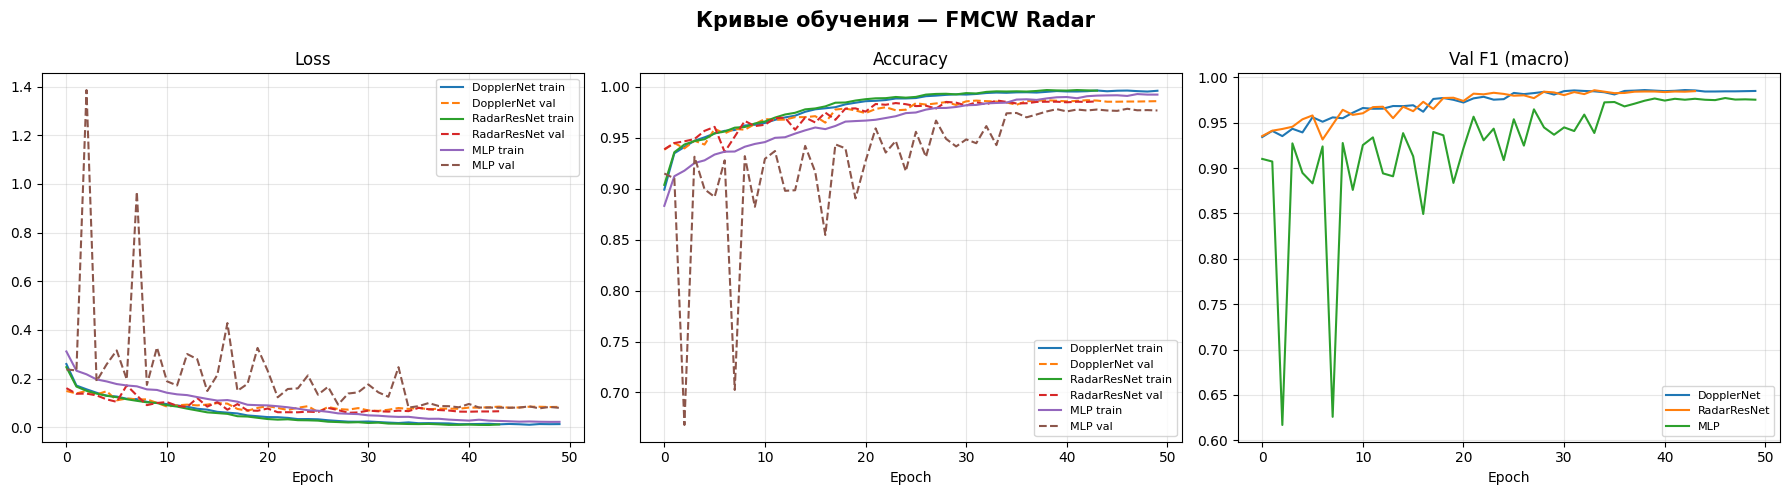

In [15]:
# Кривые обучения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
nms = ['DopplerNet','RadarResNet','MLP']
hs = [h1, h2, h3]
for h,n in zip(hs,nms):
    axes[0].plot(h['tl'],label=f'{n} train'); axes[0].plot(h['vl'],'--',label=f'{n} val')
axes[0].set_title('Loss'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3); axes[0].set_xlabel('Epoch')
for h,n in zip(hs,nms):
    axes[1].plot(h['ta'],label=f'{n} train'); axes[1].plot(h['va'],'--',label=f'{n} val')
axes[1].set_title('Accuracy'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3); axes[1].set_xlabel('Epoch')
for h,n in zip(hs,nms): axes[2].plot(h['vf'],label=n)
axes[2].set_title('Val F1 (macro)'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3); axes[2].set_xlabel('Epoch')
plt.suptitle('Кривые обучения — FMCW Radar', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_DIR/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Оценка

In [16]:
def evaluate(model, loader, name):
    model.eval()
    ps, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            o = model(x.to(DEVICE))
            ps.extend(o.argmax(1).cpu().numpy()); ys.extend(y.numpy())
    ps, ys = np.array(ps), np.array(ys)
    acc = accuracy_score(ys, ps); f1 = f1_score(ys, ps, average='macro')
    print(f'\n{"="*50}\n📊 {name} | Acc={acc:.4f} F1={f1:.4f}\n{"="*50}')
    print(classification_report(ys, ps, target_names=class_names))
    return {'model': name, 'accuracy': acc, 'f1': f1, 'preds': ps, 'labels': ys}

r1 = evaluate(m1, test_loader, 'DopplerNet')
r2 = evaluate(m2, test_loader, 'RadarResNet')
r3 = evaluate(m3, test_loader, 'MLP Baseline')


📊 DopplerNet | Acc=0.9868 F1=0.9860
              precision    recall  f1-score   support

        Cars       0.99      0.98      0.98      1716
      Drones       0.97      0.99      0.98      1520
      People       1.00      1.00      1.00      2010

    accuracy                           0.99      5246
   macro avg       0.99      0.99      0.99      5246
weighted avg       0.99      0.99      0.99      5246


📊 RadarResNet | Acc=0.9853 F1=0.9843
              precision    recall  f1-score   support

        Cars       0.99      0.97      0.98      1716
      Drones       0.96      0.99      0.98      1520
      People       1.00      1.00      1.00      2010

    accuracy                           0.99      5246
   macro avg       0.98      0.98      0.98      5246
weighted avg       0.99      0.99      0.99      5246


📊 MLP Baseline | Acc=0.9796 F1=0.9783
              precision    recall  f1-score   support

        Cars       0.98      0.96      0.97      1716
      Drones   

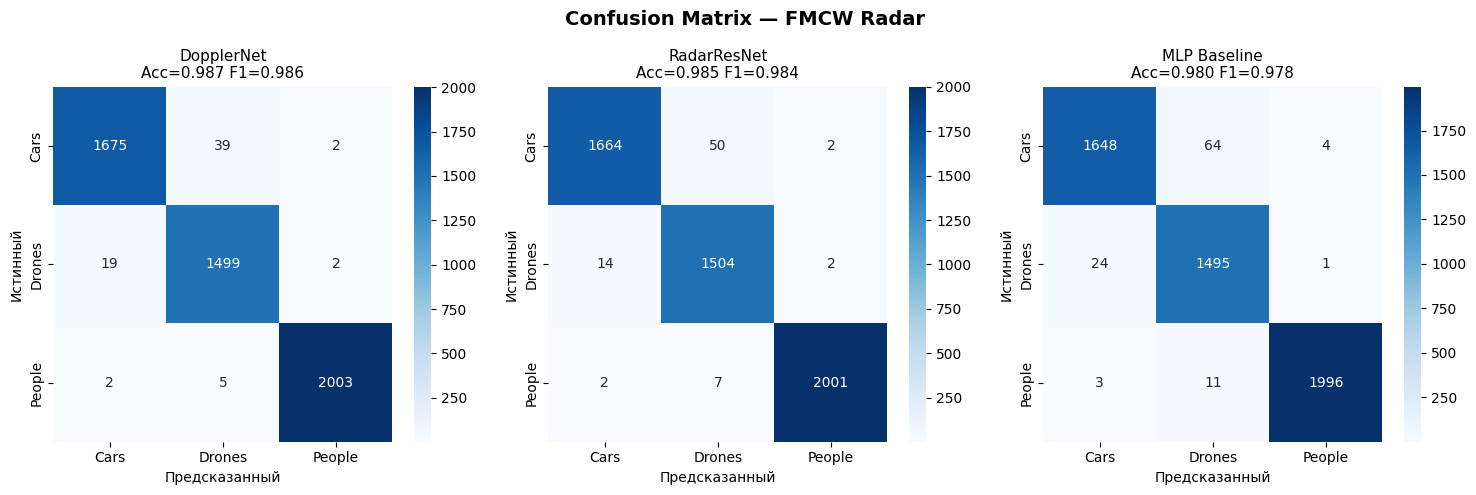

In [17]:
# Confusion matrices
all_res = [r1, r2, r3]
fig, axes = plt.subplots(1, 3, figsize=(5*3, 5))
for i, r in enumerate(all_res):
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f"{r['model']}\nAcc={r['accuracy']:.3f} F1={r['f1']:.3f}", fontsize=11)
    axes[i].set_ylabel('Истинный'); axes[i].set_xlabel('Предсказанный')
plt.suptitle('Confusion Matrix — FMCW Radar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(VIZ_DIR/'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Сравнение и экспорт

In [18]:
def bench(model, n=200):
    model.eval()
    x = torch.randn(1, 1, RD_ROWS, RD_COLS).to(DEVICE)
    with torch.no_grad():
        for _ in range(20): model(x)
    ts = []
    with torch.no_grad():
        for _ in range(n):
            t0 = time.perf_counter(); model(x)
            if torch.cuda.is_available(): torch.cuda.synchronize()
            ts.append(time.perf_counter()-t0)
    return np.mean(ts)*1000

rows = []
for model, res, nm in [(m1,r1,'DopplerNet'),(m2,r2,'RadarResNet'),(m3,r3,'MLP')]:
    p = sum(p.numel() for p in model.parameters())
    ms = bench(model)
    rows.append({'Модель': nm, 'Accuracy': f"{res['accuracy']:.4f}",
                 'F1 (macro)': f"{res['f1']:.4f}", 'Latency (ms)': f'{ms:.2f}',
                 'Params (K)': f'{p/1e3:.1f}'})

cmp = pd.DataFrame(rows)
print('📊 Сравнение моделей (FMCW Radar):')
display(cmp)
cmp.to_csv(VIZ_DIR/'radar_comparison.csv', index=False)
print(f'\n💾 Таблица: {VIZ_DIR/"radar_comparison.csv"}')

📊 Сравнение моделей (FMCW Radar):


,Модель,Accuracy,F1 (macro),Latency (ms),Params (K)
0,DopplerNet,0.9868,0.9860,0.83,271.1
1,RadarResNet,0.9853,0.9843,1.43,1922.3
2,MLP,0.9796,0.9783,0.45,510.5



💾 Таблица: /kaggle/working/visualizations/radar_comparison.csv


In [19]:
# Сводка для ВКР
best_idx = int(np.argmax([r['f1'] for r in all_res]))
best = all_res[best_idx]

summary = {
    'task': f'3-class classification: {class_names}',
    'dataset': 'Real Doppler RAD-DAR Database',
    'radar': 'FMCW 8.75 GHz, 500 MHz bandwidth',
    'input': f'Range-Doppler map {RD_ROWS}×{RD_COLS}',
    'total_samples': len(df),
    'train': len(train_df), 'val': len(val_df), 'test': len(test_df),
    'best_model': best['model'],
    'best_accuracy': f"{best['accuracy']:.4f}",
    'best_f1': f"{best['f1']:.4f}",
}

print('\n' + '='*50)
print('📋 СВОДКА ДЛЯ ВКР (Radar-модуль)')
print('='*50)
for k, v in summary.items():
    print(f'  {k:18s}: {v}')

with open(VIZ_DIR/'radar_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f'\n💾 Сводка: {VIZ_DIR/"radar_summary.json"}')


📋 СВОДКА ДЛЯ ВКР (Radar-модуль)
  task              : 3-class classification: ['Cars', 'Drones', 'People']
  dataset           : Real Doppler RAD-DAR Database
  radar             : FMCW 8.75 GHz, 500 MHz bandwidth
  input             : Range-Doppler map 11×61
  total_samples     : 34970
  train             : 24373
  val               : 5351
  test              : 5246
  best_model        : DopplerNet
  best_accuracy     : 0.9868
  best_f1           : 0.9860

💾 Сводка: /kaggle/working/visualizations/radar_summary.json


In [20]:
print('\n📥 Артефакты для скачивания:')
print('='*50)
for p, d in [
    (MODEL_DIR/'dopplernet_best.pt', 'DopplerNet веса'),
    (MODEL_DIR/'radar_resnet_best.pt', 'RadarResNet веса'),
    (MODEL_DIR/'mlp_best.pt', 'MLP веса'),
    (VIZ_DIR/'class_distribution.png', 'Распределение классов'),
    (VIZ_DIR/'rd_map_examples.png', 'Примеры RD-карт'),
    (VIZ_DIR/'mean_rd_maps.png', 'Средние RD-карты'),
    (VIZ_DIR/'signal_statistics.png', 'Статистика сигналов'),
    (VIZ_DIR/'training_curves.png', 'Кривые обучения'),
    (VIZ_DIR/'confusion_matrices.png', 'Confusion matrices'),
    (VIZ_DIR/'radar_comparison.csv', 'Таблица сравнения'),
    (VIZ_DIR/'radar_summary.json', 'Сводка метрик'),
]:
    if Path(p).exists():
        print(f'  ✅ {d:25s} — {Path(p).name} ({Path(p).stat().st_size/1e3:.1f} KB)')
    else:
        print(f'  ⬜ {d}')
print(f'\n   Kaggle: Output → Download All')


📥 Артефакты для скачивания:
  ✅ DopplerNet веса           — dopplernet_best.pt (1100.3 KB)
  ✅ RadarResNet веса          — radar_resnet_best.pt (7722.4 KB)
  ✅ MLP веса                  — mlp_best.pt (2057.0 KB)
  ✅ Распределение классов     — class_distribution.png (39.9 KB)
  ✅ Примеры RD-карт           — rd_map_examples.png (188.9 KB)
  ✅ Средние RD-карты          — mean_rd_maps.png (186.1 KB)
  ✅ Статистика сигналов       — signal_statistics.png (59.9 KB)
  ✅ Кривые обучения           — training_curves.png (250.8 KB)
  ✅ Confusion matrices        — confusion_matrices.png (86.6 KB)
  ✅ Таблица сравнения         — radar_comparison.csv (0.2 KB)
  ✅ Сводка метрик             — radar_summary.json (0.4 KB)

   Kaggle: Output → Download All
